In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans

# Exercice 1

## Question 1

On va utiliser la méthode de la transformée inverse.

Avec $U \sim \mathcal U([0,1])$, supposons qu'il existe une fonction $g$ telle que $Y = g(U)$ suit la probabilité $\mathbb P$ désirée.

Dans ce cas, on a pour la fonction de répartition de $\mathbb P$ :
$$
F_{P}(x) = \mathbb P(Y \leq x) = \mathbb P(g(U) \leq x) = \mathbb P(U \leq g^{-1}(x)) = g^{-1}(x)
$$

Le seul souci dans notre cas est que $F_P$ est une fonction en escalier et n'est pas inversible au sens classique. Mais on sait que la méthode marche avec l'inverse généralisé : au lieu d'utiliser $F^{-1}$, on utilise la fonction quantile
$$
Q(u) = \inf\{x : F_P(x) \geq u\}.
$$

Dans notre cas, la fonction de répartition discrète de $Y$ est une fonction en escalier:
$$
F_P(x)
= \mathbb P(Y \le x)
= \sum_{k=1}^K \pi_k \,\mathbb{1}_{\{v_k \le x\}},
$$

Ceci nous donne le pseudocode suivant :
- On génère $U \sim \mathcal U([0,1])$.
- On compare $U$ avec $F_P$  : on cherche l’indice $i$ tel que
  $$
  F_P(v_{i-1}) < U \le F_P(v_i)
  \quad (\text{en posant } F_P(v_0) = 0 \text{ et en prenant $v_{1}$ si $U =0$}).
  $$
- On prend alors la valeur correspondante $v_i$, c’est-à-dire on pose $Y = v_i$.




## Question 2

In [2]:
def generateY(p_list,v_list):
    cdf = [0]
    s = 0
    for p in p_list:
        s+=p
        cdf.append(s)
        
    # U dans U[0,1]
    U = np.random.uniform(low = 0, high = 1)
    
    j = 0
    # j tel que cdf[j] < U <= cdf[j+1]
    while U>cdf[j+1]:
        j += 1
    return v_list[j]
        

## Question 3

In [3]:
v_list = [1,2,3,4,5]
p_list = [0.1, 0.3, 0.5,0.05,0.05]
N = 10000

In [38]:
sample = [generateY(p_list,v_list) for i in range(10000)]

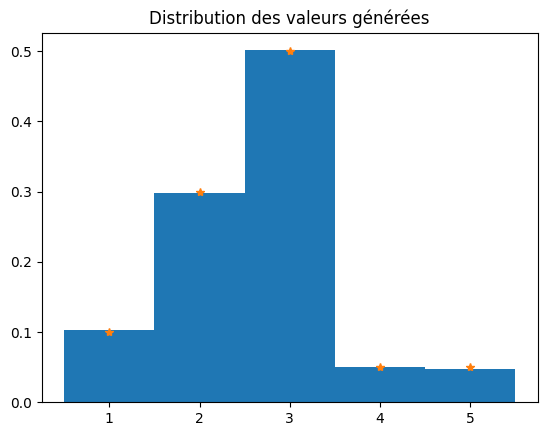

In [39]:
bins = [0.5,1.5,2.5,3.5,4.5,5.5]
plt.hist(sample, bins=bins, density= True) #densité générée
plt.plot(v_list, p_list, '*') #densité réelle
plt.title('Distribution des valeurs générées')
plt.show()

# Exercice 2
## Question 1

On cherche à estimer les valeurs $\alpha_{k}, \mu_{k}, \Sigma_{k}$ pour chaque cluster. On note donc
$$
\theta =
\begin{pmatrix}
(\alpha_{k})_{k} \\
(\mu_{k})_{k} \\
(\Sigma_{k})_{k}
\end{pmatrix}
$$


Pour une gaussienne de moyenne $\mu$ et de matrice de covariance $\Sigma$, on a la densité
$$
f_{\mu,\Sigma}(x)=\frac{1}{(2\pi)^{d/2}\lvert \Sigma \rvert^{1/2}  }\exp(-\frac{(x-\mu)^T \Sigma^{-1}(x-\mu)}{2}) 
$$


Pour un mélange gaussien, la densité marginale de $X_i$ s’écrit alors, pour tout $x_i$,
$$
f_\theta(x_i)
= \sum_{k=1}^m \alpha_k \, f_{\mu_k,\Sigma_k}(x_i).
$$

Ainsi, la vraisemblance associée à l’échantillon $(X_i)_{i}$ avec $X_{i}$ IID est
$$
L(x_1,\dots,x_n; \theta)= \prod_{i=1}^n \left( \sum_{k=1}^m \alpha_k f_{\mu_k,\Sigma_k}(x_i) \right).
$$


## Question 2
On va générer un échantilllon de notre mélange gaussien.

In [6]:
#generation de paramètres
v_list_mixture = [0,1,2,3]
p_list_mixture = [0.1, 0.3, 0.5,0.1]

sigmas_mixture = []
means_mixture = []

for i in range(4):
    
    sigma= np.random.uniform(size = (2,2), low=-1,high=1)
    sigma = sigma@np.transpose(sigma)
    sigmas_mixture.append(sigma)

means_mixture = np.random.randint(low = 0, high = 5, size = (4,2))
sigmas_mixture,means_mixture

([array([[ 0.56243151, -0.27021761],
         [-0.27021761,  1.4032286 ]]),
  array([[ 1.76578409, -0.21262697],
         [-0.21262697,  0.02572829]]),
  array([[0.8435025 , 0.38117095],
         [0.38117095, 0.2814628 ]]),
  array([[0.86636209, 0.36134164],
         [0.36134164, 0.18320575]])],
 array([[0, 0],
        [0, 2],
        [1, 0],
        [4, 1]]))

In [7]:
def sampleX(means_mixture,sigmas_mixture,p_list_mixture,v_list_mixture):
    Z = generateY(p_list_mixture,v_list_mixture)
    X = np.random.multivariate_normal(mean = means_mixture[Z],cov=sigmas_mixture[Z])
    return X,Z

In [8]:
# testing
X,Z = sampleX(means_mixture,sigmas_mixture,p_list_mixture,v_list_mixture)
X,Z

(array([1.52386153, 0.25529001]), 2)

In [9]:
#generation sample
N_mixture = 5000
sample = []
label = []
for i in range(N_mixture):
    X,Z = sampleX(means_mixture,sigmas_mixture,p_list_mixture,v_list_mixture)
    sample.append(X)
    label.append(Z)

samples = np.array(sample)
labels = np.array(label)
print("Taille samples:", samples.shape)
print("Taille labels:", labels.shape)

Taille samples: (5000, 2)
Taille labels: (5000,)


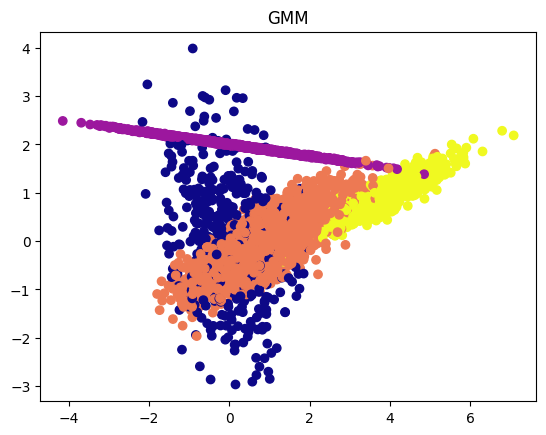

In [10]:
plt.scatter(samples[:, 0], samples[:, 1], c=labels, cmap = 'plasma')
plt.title('GMM')
plt.show()

## Question 3

Notons d'abord le pseudo-code de notre algorithme EM pour un mélange gaussien.

- $M_0$ : on initialise les paramètres avec k-means.

On répète :

- **E-step** : on estime les responsabilités $\tau_{ik}$ avec
  $$
  \tau_{ik}
  = \frac{\alpha_k\, f_{\mu_k,\Sigma_k}(x_i)}
         {\sum_{\ell=1}^K \alpha_\ell\, f_{\mu_\ell,\Sigma_\ell}(x_i)},
  $$
  où
  $$
  f_{\mu,\Sigma}(x)
  = \frac{1}{(2\pi)^{d/2}\lvert \Sigma \rvert^{1/2}}
    \exp\!\left(-\frac{(x-\mu)^\top \Sigma^{-1}(x-\mu)}{2}\right).
  $$

- **M-step** : on maximise l’ELBO, ce qui revient ici à mettre à jour des paramètres:
  
  $$
  N_k = \sum_{i=1}^N \tau_{ik}.
  $$

  $$
  \hat{\alpha}_k = \frac{N_k}{N},
  $$
  $$
  \hat{\mu}_k = \frac{1}{N_k} \sum_{i=1}^N \tau_{ik}\, x_i,
  $$
  $$
  \hat{\Sigma}_k
  = \frac{1}{N_k} \sum_{i=1}^N \tau_{ik}
    (x_i - \hat{\mu}_k)(x_i - \hat{\mu}_k)^\top.
  $$


In [11]:
def eval_normal_density(xi,mu,sigma):
    # dim = 2
    return 1/(2*np.pi*np.sqrt(np.linalg.det(sigma)))*np.exp(-0.5*np.transpose(xi-mu)@np.linalg.inv(sigma)@(xi-mu))

def EM(X, K=3, iter=50,plot = False):
    # init avec kmeans
    N_mixture = X.shape[0]
    kmeans = KMeans(n_clusters=K, random_state=0, init = 'k-means++').fit(X)
    labels = kmeans.labels_
    means = kmeans.cluster_centers_
    means = np.array(means) 
    alphas = np.zeros(K)
    sigmas = np.zeros((K, 2, 2))
    for i in range(K):
        sigmas[i] = np.transpose(X[labels == i]-means[i])@(X[labels == i]-means[i])/(labels==i).sum()
        alphas[i] = (labels==i).sum()/N_mixture
    if plot:
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap = 'plasma',alpha = 0.3)
        plt.title('Init Kmeans')
        plt.show()
       
    for i in range(iter):
        # E-step
        taus = np.zeros((N_mixture,K))
        for k in range(K):
            for l in range(N_mixture):
                taus[l,k] = eval_normal_density(X[l],means[k],sigmas[k])
        taus = taus * alphas
        taus = taus/taus.sum(axis=1,keepdims= True)
         
        # M-step
        alphas = taus.sum(axis = 0)/N_mixture
        means =  np.transpose(taus)@X
        Nk = taus.sum(axis = 0)
        for j in range(K):
            means[j] = means[j]/Nk[j]
            sigmas[j] = np.transpose(taus[:,j])*np.transpose(X-means[j])@(X-means[j])/ Nk[j]

        #print(i)
        labels = np.argmax(taus,axis = 1)
    if plot:
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap = 'plasma',alpha = 0.3)
        plt.title('Result EM')
        plt.show()
    return means,sigmas,alphas,labels

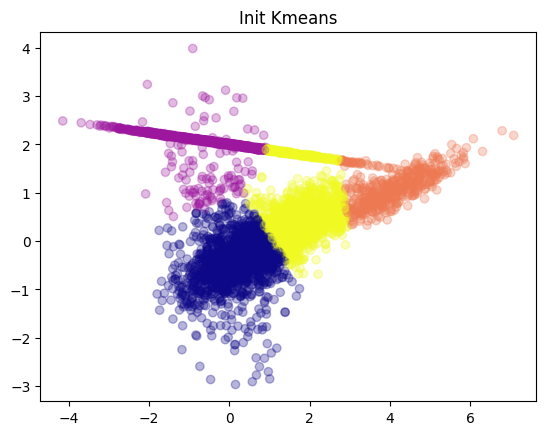

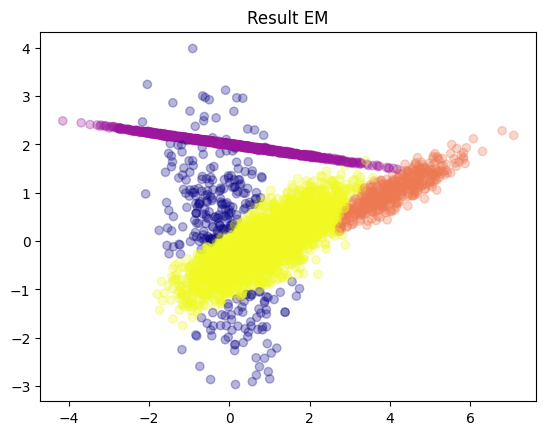

In [12]:
estim_means,estim_sigmas,estim_alphas,estim_labels = EM(samples,K=4, plot = True)


## Question 4

In [13]:
# re-order
K=4
order_true = np.argsort(means_mixture[:, 0])
order_em = np.argsort(estim_means[:, 0])
em_means = estim_means[order_em]
true_means = means_mixture[order_true]
em_alphas = estim_alphas[order_em]
true_alphas = np.array(p_list_mixture)[order_true]
em_sigmas = estim_sigmas[order_em]
true_sigmas = np.array(sigmas_mixture)[order_true]

total_alpha_dist = 0.0
total_mean_dist  = 0.0
total_sigma_dist = 0.0

# print les params cluster par cluster
for k in range(K):
    alpha_dist = abs(true_alphas[k] - em_alphas[k])
    mean_dist  = np.linalg.norm(true_means[k] - em_means[k])                  # L2
    sigma_dist = np.linalg.norm(true_sigmas[k] - em_sigmas[k], ord='fro')     # Frobenius

    print('Cluster:',k)
    print('True:',true_alphas[k],'EM:',em_alphas[k], 'dist:', alpha_dist)
    print('True:',true_means[k],'EM:', em_means[k], 'dist:', mean_dist)
    print('True:',true_sigmas[k],'EM:',em_sigmas[k], 'dist:', sigma_dist)
    print('')
    
    total_alpha_dist += alpha_dist
    total_mean_dist  += mean_dist
    total_sigma_dist += sigma_dist
    

print('Total alpha dist', total_alpha_dist)
print('Total mean dist', total_mean_dist)
print('Total sigma dist', total_sigma_dist)

Cluster: 0
True: 0.1 EM: 0.0886691234524256 dist: 0.011330876547574406
True: [0 0] EM: [-0.09283558  0.04503882] dist: 0.103184010038008
True: [[ 0.56243151 -0.27021761]
 [-0.27021761  1.4032286 ]] EM: [[ 0.52559062 -0.27227227]
 [-0.27227227  1.48428798]] dist: 0.08908601740263634

Cluster: 1
True: 0.3 EM: 0.30815102699400443 dist: 0.00815102699400444
True: [0 2] EM: [0.04350766 1.99456414] dist: 0.043845920937236015
True: [[ 1.76578409 -0.21262697]
 [-0.21262697  0.02572829]] EM: [[ 1.71625305 -0.20740992]
 [-0.20740992  0.02518804]] dist: 0.050080447769044044

Cluster: 2
True: 0.5 EM: 0.5139399986321269 dist: 0.013939998632126915
True: [1 0] EM: [ 0.9692429  -0.01934917] dist: 0.03633716804644482
True: [[0.8435025  0.38117095]
 [0.38117095 0.2814628 ]] EM: [[0.84803474 0.38370953]
 [0.38370953 0.28505941]] dist: 0.0068092317323834705

Cluster: 3
True: 0.1 EM: 0.08923985092144227 dist: 0.01076014907855774
True: [4 1] EM: [4.03466242 1.01131834] dist: 0.03646352116637646
True: [[0.866

**Conclusion:**

Les valeurs estimées semble être suffisamment proches des valeurs initiales.

**Traçons les clusters pour s'en assurer:**

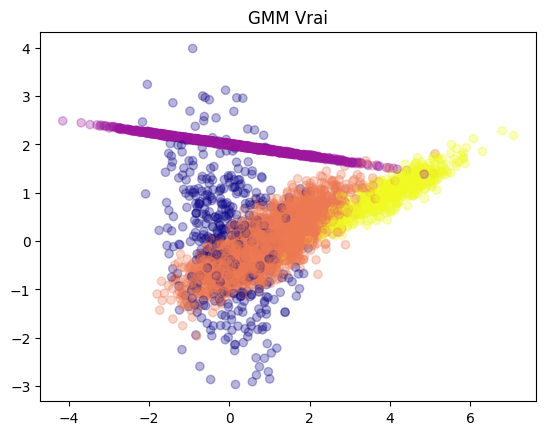

In [14]:
plt.scatter(samples[:, 0], samples[:, 1], c=labels, cmap = 'plasma',alpha = 0.3)
plt.title('GMM Vrai')
plt.show()

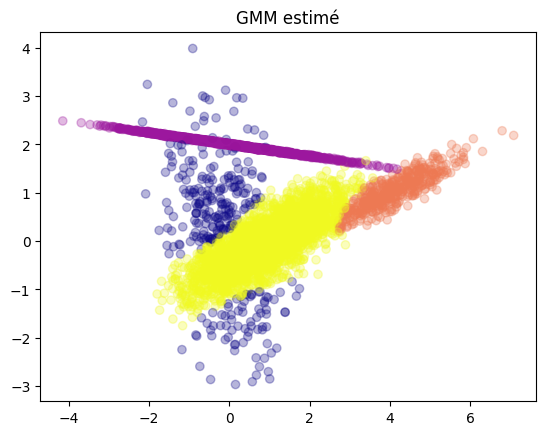

In [15]:
plt.scatter(samples[:, 0], samples[:, 1], c=estim_labels, cmap = 'plasma',alpha = 0.3)
plt.title('GMM estimé')
plt.show()

## Question 5

/var/folders/md/4f5pxc7917bdyyrnr824zglh0000gn/T/ipykernel_26437/3002016677.py:2: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('WPP2024_Demographic_Indicators_Medium.csv')


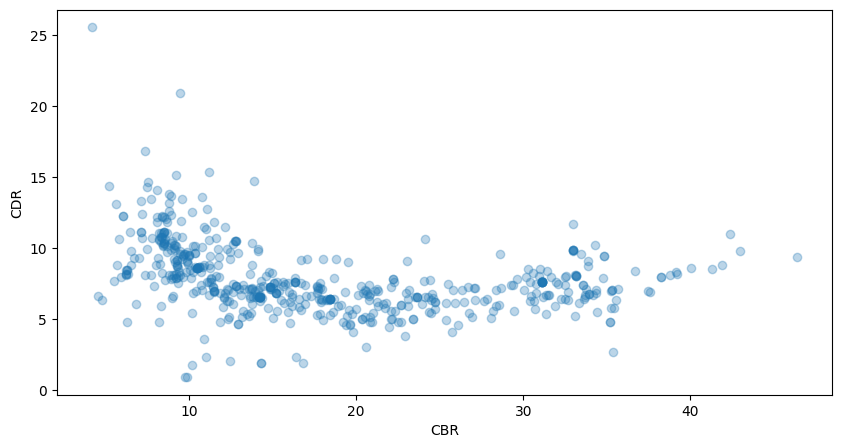

In [16]:
# Chargement la data 
data = pd.read_csv('WPP2024_Demographic_Indicators_Medium.csv')
data = data[data['Time']==2023]
data = data[['CBR','CDR']].dropna()
X = np.array(data)

# Plot
plt.figure(figsize= (10,5))
plt.scatter(X[:,0],X[:,1], alpha = 0.3)
plt.xlabel('CBR')
plt.ylabel('CDR')
plt.show()

**Interpretation:**

À l’oeil, il est difficile d’identifier un nombre clair de groupes: les observations forment plutôt une masse compacte, de forme légèrement courbée, plutôt que des clusters bien séparés. On observe également la présence de quelques valeurs extrêmes.

In [17]:
estim_means,estim_sigmas,estim_alphas,estim_labels = EM(X,K=3)

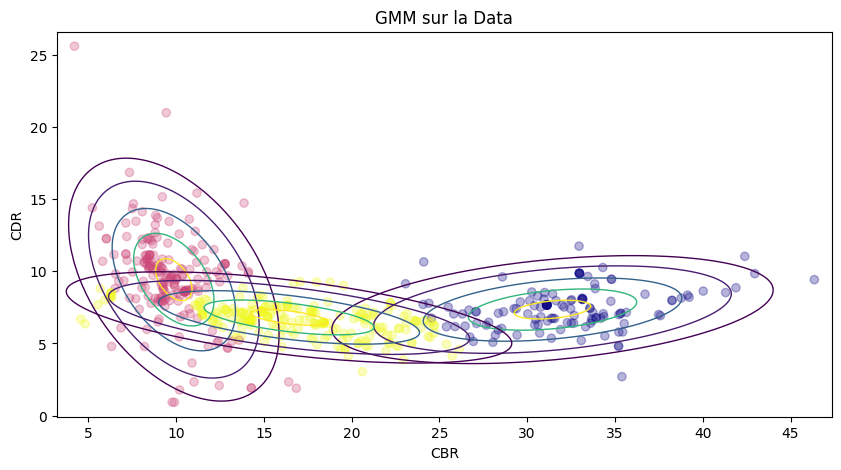

In [18]:
plt.figure(figsize= (10,5))
plt.scatter(X[:, 0], X[:, 1], c=estim_labels, cmap='plasma', alpha=0.3)

# grille contours
xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1

N_grid = 200
Xg = np.linspace(xmin, xmax, N_grid)
Yg = np.linspace(ymin, ymax, N_grid)
Xg, Yg = np.meshgrid(Xg, Yg)
pos = np.dstack((Xg, Yg))

K = estim_means.shape[0]

for k in range(K):
    rv = multivariate_normal(mean=estim_means[k], cov=estim_sigmas[k], allow_singular=True)
    Z = rv.pdf(pos)
    
    zmax = Z.max()
    levels = [0.03 * zmax,0.1 * zmax, 0.3 * zmax, 0.6 * zmax, 0.9*zmax]
    plt.contour(Xg, Yg, Z, levels=levels, cmap = 'viridis',linewidths=1)

plt.title('GMM sur la Data')
plt.xlabel('CBR')
plt.ylabel('CDR')
plt.show()


**Interpretation:**
- Cluster de gauche: il regroupe des pays à faible natalité, avec une mortalité plus variable. La gaussienne est légèrement inclinée vers le bas, ce qui suggère qu’au sein de ce groupe, une natalité un peu plus élevée est associée à une mortalité légèrement plus faible.
- Cluster central : il correspond à des pays avec une mortalité faible et peu dispersée, alors que la natalité varie davantage. Géométriquement, la composante est assez “plate” horizontalement : cela indique une faible corrélation entre CBR et CDR dans cette zone.  
- Cluster de droite : il ressemble au cluster central, mais avec une natalité plus forte.

## Question 7
On va utiliser le BIC pour estimer le meilleur nombre de clusters. 
On a 
$$\text{BIC}(m)=  - \log L(x_1,\dots,x_n;\hat\theta_m)+ \frac{df(m)\log n}{2}$$

avec $L(x_1,\dots,x_n; \hat{\theta}_{m})= \prod_{i=1}^n \left( \sum_{k=1}^m \alpha_k f_{\hat{\mu}_k,\hat{\Sigma}_k}(x_i) \right)$

Calculons le nombre de paramètres: 
- pour les $\alpha_{i}$: m paramètres et une contrainte ($\sum=1$): $m-1$ paramètres au total
- moyennes: chaque moyenne est de taille 2, donc $m\times 2$ paramètres
- covariances: les matrices sont symétriques de taille $2\times2$ donc on va avoir $m \times 3$ paramètres
Ainsi: 
$$df = 6m-1$$
 (en dimension 2)

In [19]:
def log_likelihood(X, alphas, means, sigmas): 
    X = np.array(X)
    n = X.shape[0]
    m = alphas.shape[0]
    logL = 0
    for i in range(n):
        s = 0
        for k in range(m):
            s += alphas[k] * eval_normal_density(X[i], means[k], sigmas[k])
        logL += np.log(s)

    return logL

def df(m):
    return 6*m-1

def BIC(m, X,alphas,means,sigmas):
    n = X.shape[0]
    BIC_m = - log_likelihood(X, alphas, means, sigmas) + 0.5 * df(m) * np.log(n)
    return BIC_m

In [20]:
def plot_EM(estim_means,estim_sigmas,estim_labels, m):
    
    plt.figure(figsize=(5, 10))
    plt.scatter(X[:, 0], X[:, 1], c=estim_labels, cmap='plasma', alpha=0.3)

    # grille contours
    xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
    ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1

    N_grid = 200
    Xg = np.linspace(xmin, xmax, N_grid)
    Yg = np.linspace(ymin, ymax, N_grid)
    Xg, Yg = np.meshgrid(Xg, Yg)
    pos = np.dstack((Xg, Yg))

    K = estim_means.shape[0]

    for k in range(K):
        rv = multivariate_normal(mean=estim_means[k], cov=estim_sigmas[k], allow_singular=True)
        Z = rv.pdf(pos)
        
        zmax = Z.max()
        levels = [0.03 * zmax,0.1 * zmax, 0.3 * zmax, 0.6 * zmax, 0.9*zmax]
        plt.contour(Xg, Yg, Z, levels=levels, cmap = 'viridis',linewidths=1)

    plt.title(f'GMM estimé, {m} clusters')
    plt.xlabel('CBR')
    plt.ylabel('CDR')
    plt.show()
    return


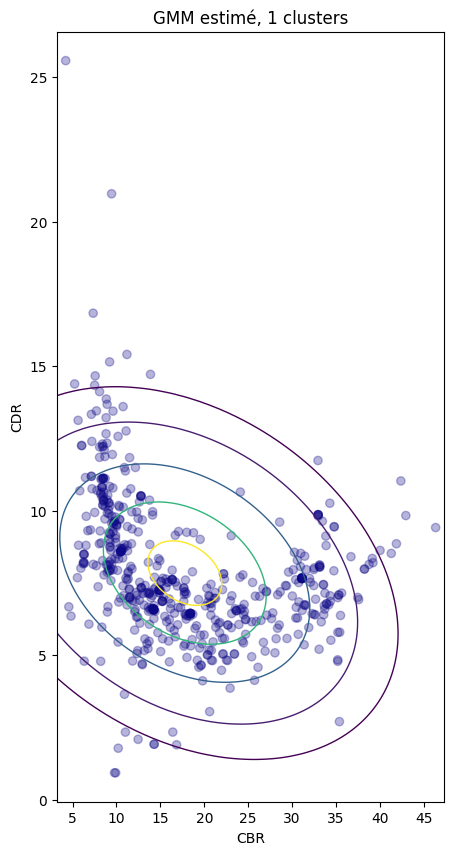

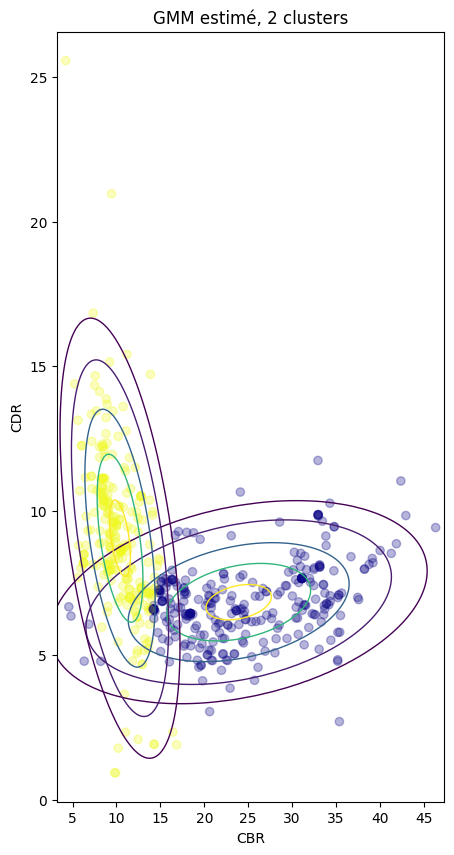

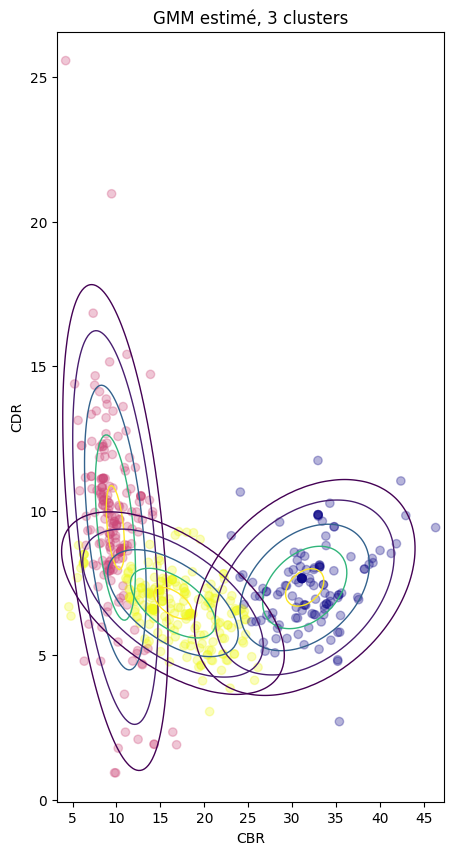

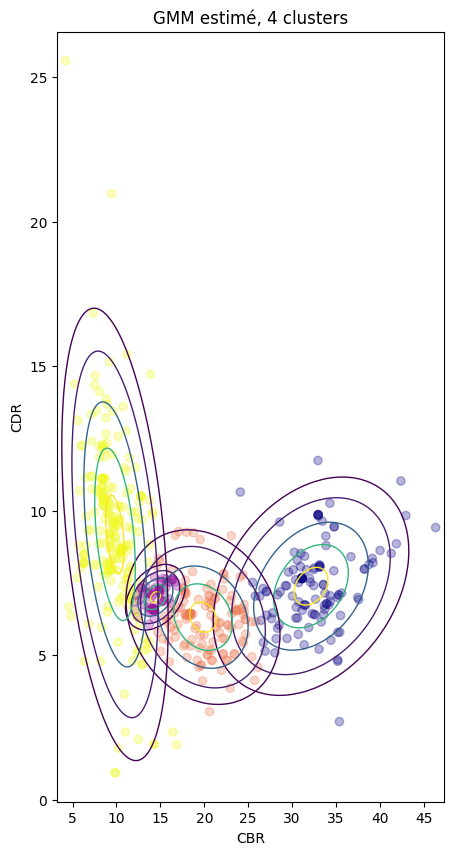

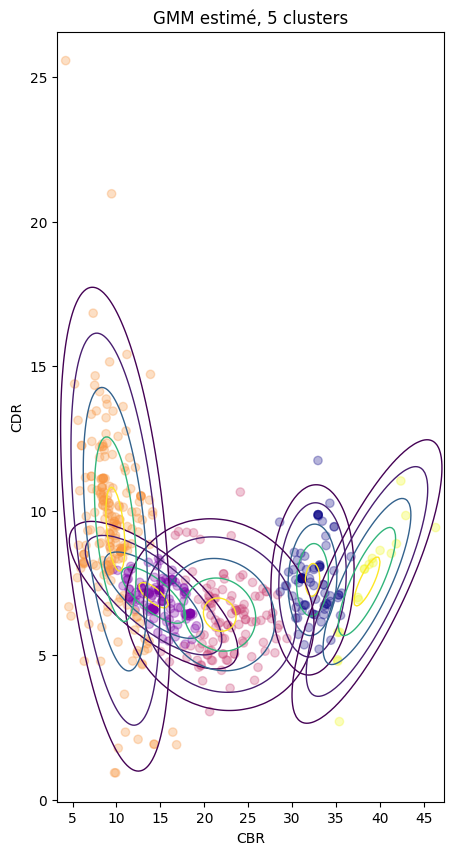

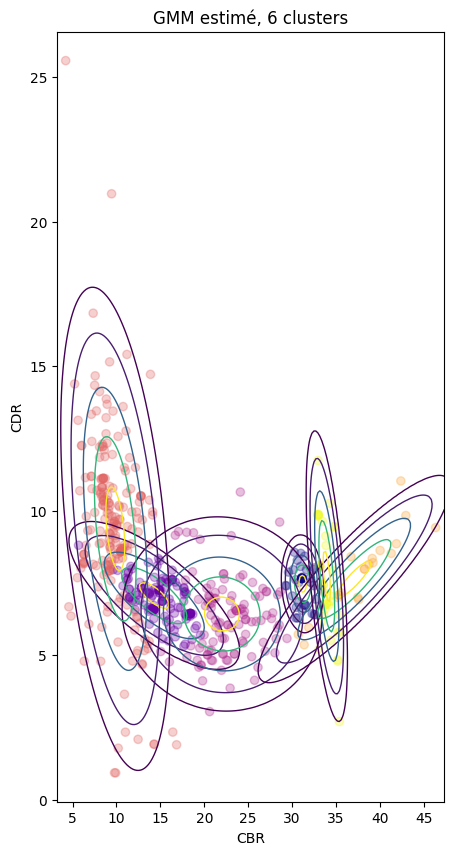

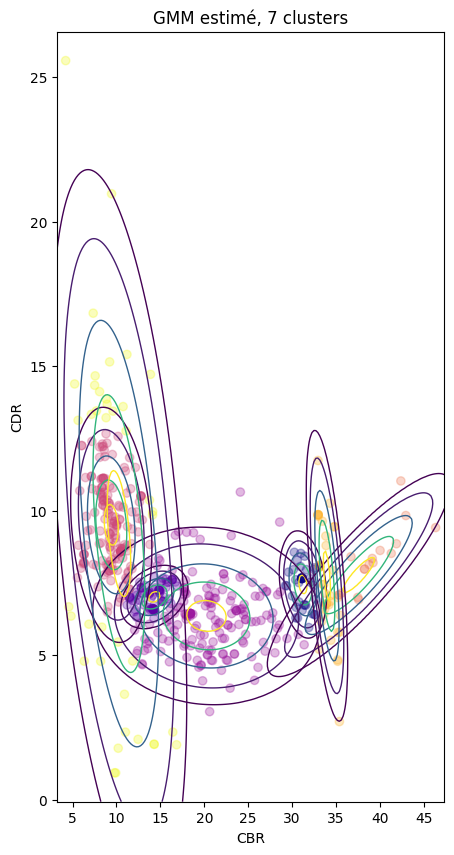

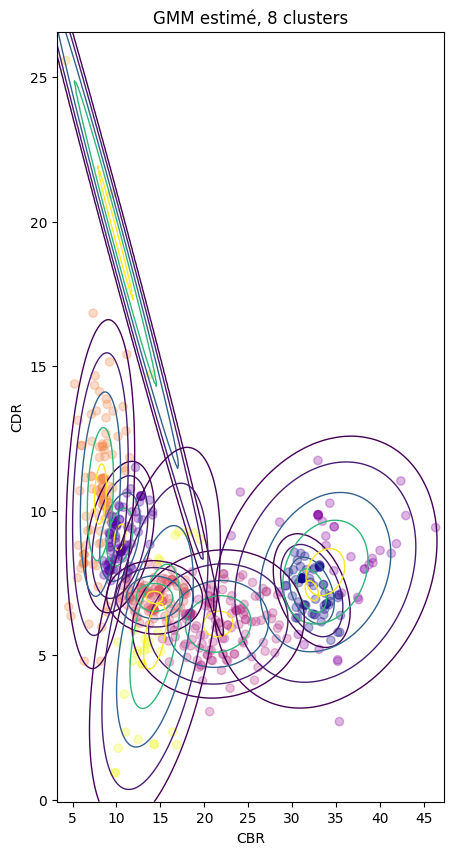

In [21]:
BICs = []
for m in range(1,9):
    estim_means,estim_sigmas,estim_alphas,estim_labels = EM(X,K=m)
    plot_EM(estim_means,estim_sigmas,estim_labels,m)
    BICs.append(BIC(m, X,estim_alphas,estim_means,estim_sigmas))


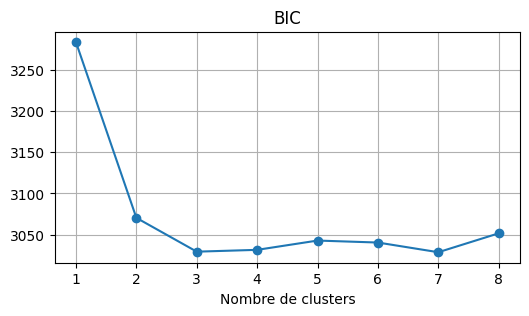

Meilleur K selon BIC : 7


In [22]:
fig = plt.figure(figsize=(6, 3))
plt.plot(range(1,9),BICs,'o-')
plt.title('BIC')
plt.xlabel('Nombre de clusters')
plt.grid()
plt.show()

best_K = np.argmin(BICs) + 1 #reajuste l'index 
print("Meilleur K selon BIC :", best_K)

# Exercice 3.A
## Question 1
On va échantillonner $Y$ selon la loi $Q$ qui est en fait une gaussienne de moyenne $0.8$ et d'écart type $1.5$

In [23]:
mu = 0.8
sigma2 = 1.5

def f(x): 
    if x < 0:
        return 0
    else:
        f = 2* np.sin(np.pi * x/1.5)
        return f 
    
    
def p(x): 
    if x<0:
        return 0
    else:
        p = x**(1.65 - 1) * np.exp(-x**2/2)
        return p

def q(x, mu, sigma2):
    return (2/np.sqrt(2*np.pi*sigma2))*np.exp(-((mu - x)**2)/(2*sigma2))

def sampleY_q(mu, sigma2):
    Y = np.random.normal(loc= mu, scale=np.sqrt(sigma2))
    while Y<0:
         Y = np.random.normal(loc= mu, scale=np.sqrt(sigma2))
    return Y


In [24]:
def import_sampling(N, mu, sigma2):
    points = np.array([sampleY_q(mu,sigma2) for _ in range(N)])
    weights = np.array([p(x)/q(x, mu, sigma2) for x in points])
    values  = np.array([f(x) for x in points])  
    return np.sum(values * weights) / np.sum(weights) # besoin de normaliser

In [25]:
N_list = [10,100,1000,10000]
for N in N_list:
    Esp = import_sampling(N,mu,sigma2)
    print(f'Nombre de samples:',N,', estimateur:',Esp)

Nombre de samples: 10 , estimateur: 1.5321310593444166
Nombre de samples: 100 , estimateur: 0.901141304024758
Nombre de samples: 1000 , estimateur: 0.7551387908982734
Nombre de samples: 10000 , estimateur: 0.7615221654488218


## Question 2

In [26]:
n = 100 # nombre d'estimateurs

est = []
for i in range(n):
    est.append([import_sampling(N,mu,sigma2) for N in N_list])

est = np.array(est)

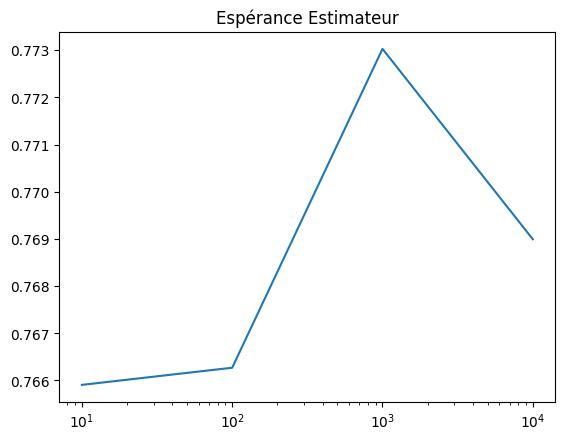

In [27]:
plt.plot(N_list,(est.mean(axis = 0)))
plt.xscale("log")
plt.title('Espérance Estimateur')
plt.show()

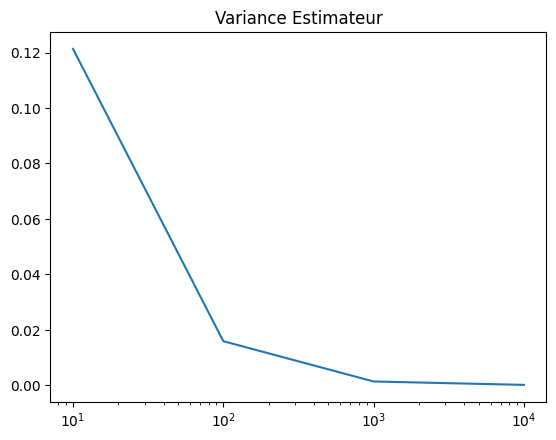

In [28]:
plt.plot(N_list,(est.var(axis = 0)))
plt.xscale("log")
plt.title('Variance Estimateur')
plt.show()

## Question 3

In [29]:
new_mu = 6
mu= 0.8
N = 10000

In [30]:
points  = np.array([sampleY_q(mu, sigma2) for _ in range(N)])
w = np.array([p(x) / q(x, mu, sigma2) for x in points])
w = w / w.sum()  # poids normalisés

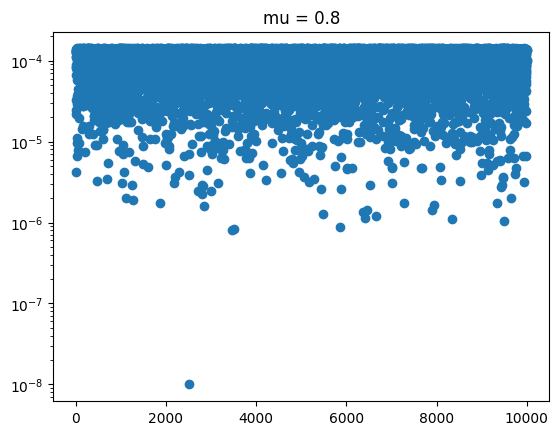

In [31]:
plt.plot(w,'o')
plt.title('mu = 0.8')
plt.yscale('log')
plt.show()

In [32]:
points  = np.array([sampleY_q(new_mu, sigma2) for _ in range(N)])
new_w = np.array([p(x) / q(x, new_mu, sigma2) for x in points])
new_w = new_w / new_w.sum()  # poids normalisés

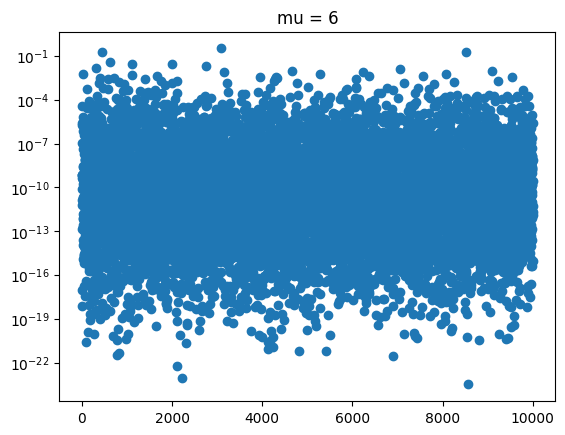

In [33]:
plt.plot(new_w,'o')
plt.title('mu = 6')
plt.yscale('log')
plt.show()

**Interpretation:**

Les poids avec $\mu=0.8$ sont plus homogènes, la plupart des échantillons ont une contribution comparable dans l’estimateur. Cependant, avec $\mu = 6$ une grande partie des points a un poids négligeable devant quelques échantillons qui concentrent presque toute la masse. Les échantillons avec le petit poids n’apportent pratiquement pas d’information. Cela nous montre l'importance de bien choisir la distribution $q$ pour faire de l'importance sampling.